In [1]:
import pandas as pd
import subprocess
from functools import reduce
import numpy as np
import umap
from plotnine import *
import os
import pickle
import glob
import time
from itertools import product


/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import simulations.genomes1000_sim as sim_functions

intermediate_plink_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_plink'
intermediate_saige_dir ='/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/intermediate_saige'
root_dir = '/gpfs/commons/datasets/1000genomes'
igsr_samples_filepath = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/input/igsr_samples.tsv'
output_dir = '/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output'
admixture_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5'
map_filepath = f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.map'

In [3]:
# PARAMETERS
generate_sim = True
evaluate_sim = True
# generate all combinations of e and ps variables
ps_list = [True,False]
e_list = [0.5,1]
num_markers_assoc_list = [100,2000]
init_list = range(100) # 100 random initializations for each combination
bfile_path=f'{output_dir}/G'
af_df_filepath=admixture_filepath
# PARAMETERS

## Explore 1000 genomes data

### Run GWAS with and without PCs and see how much genetic coefficients change 

how many samples overlap between subgroups?

### Algorithm creation

In [38]:
# empirically, show monotone decrease of loss and stabilization over iterations
# show stability of parameter norms (U^t-U^(t-1))

# JointMF
import algorithms.SCoNE as SCoNE
import algorithms.MLFlowWrapper as MLFlowWrapper
import evaluation.cluster_evaluation as cluster_evaluation
import importlib
importlib.reload(SCoNE)

writer = None

# read in simulated clinical data
ps = True
e = 0.25
init = 0
num_markers_assoc = 100
output_suffix = f'ps_{ps}_e_{e}_init_{init}_markersassoc_{num_markers_assoc}'
C = np.load(f'{output_dir}/C_{output_suffix}.npy')
with open(f"{output_dir}/simulation_metadata_{output_suffix}.pkl", "rb") as f:
    simulation_metadata = pickle.load(f)

# read in admixture fractions, sex and G
igsr_samples = sim_functions.read_in_igsr_samples(igsr_samples_filepath, bfile_path=f'{output_dir}/G')
igsr_samples['Sex'] = igsr_samples['Sex'].map({'female': 0, 'male': 1})

admixture = pd.read_csv(f'{root_dir}/release-20130502-supporting/admixture_files/ALL.wgs.phase3_shapeit2_filtered.20141217.maf0.05.5.Q',sep='\s+',header=None)
fam_df = pd.read_csv(f'{output_dir}/G.fam',sep='\s+',header=None)
fam_df.columns = ['FID','IID'] + fam_df.columns[2:].tolist()
admixture['IID'] = fam_df['IID'].values
Z_df = admixture.merge(igsr_samples[['IID','Sex']], on='IID',how='inner')
Z = Z_df[[i for i in Z_df.columns if i!='IID']].to_numpy()

G = np.loadtxt(f'{output_dir}/G.raw',  usecols=range(6, 10000+6), dtype=np.int8, skiprows=1)
G = (G>0).astype(np.int8)
# assert that bim_df and G order is the same
bfile_path = f'{output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
G_columns = [i.split('_')[0] for i in pd.read_csv(f'{bfile_path}.raw',sep='\s+',usecols=range(6, 10000+6),nrows=1).columns]
assert all(bim_df['SNP'].values==G_columns)



In [39]:
rank = 3
(lambda_W, lambda_H_G, lambda_H_C) = (0,0,0)
col = 100
W = np.random.random((G[:,:col].shape[0], rank))*1e-2+1e-6 
H_G = np.random.random((G[:,:col].shape[1], rank))*1e-2+1e-6
H_C = np.random.random((C.shape[1], rank))*1e-2+1e-6
U_G = np.random.random((G[:,:col].shape[1], Z.shape[1]))*1e-2+1e-6
U_C = np.random.random((C.shape[1], Z.shape[1]))*1e-2+1e-6
factor_matrices_noz, loss_function_noz = SCoNE.alternating_opt(G[:,:col],C,np.zeros((Z.shape[0],Z.shape[1])),W, H_G, H_C, U_G, U_C,lambda_W, lambda_H_G, lambda_H_C, 
    method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':20, 'ftol':1e-6},tol=1e-4,nonneg=True, C_loss_type=None, G_loss_type=None)


In [42]:
factor_matrices_noz["W"] == W/np.linalg.norm(W, axis=0)

array([[False, False, False],
       [False, False, False],
       [False, False, False],
       ...,
       [False, False, False],
       [False, False, False],
       [False, False, False]])

ML Flow practice

In [16]:
import mlflow
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("file:/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs")
client = MlflowClient()

# Get all experiments
experiments = client.search_experiments()
assert len(experiments) == 16
all_runs = []
for exp in experiments:
    print(exp)
    df = mlflow.search_runs([exp.experiment_id])
    if not df.empty:
        df["experiment_id"] = exp.experiment_id
        df["experiment_name"] = exp.name
        all_runs.append(df)

<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/278049064748695367', creation_time=1758233676261, experiment_id='278049064748695367', last_update_time=1758233676261, lifecycle_stage='active', name='15', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/975916140127120521', creation_time=1758233676251, experiment_id='975916140127120521', last_update_time=1758233676251, lifecycle_stage='active', name='14', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/461302518101554748', creation_time=1758233676243, experiment_id='461302518101554748', last_update_time=1758233676243, lifecycle_stage='active', name='13', tags={}>
<Experiment: artifact_location='file:///gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/494235057889664105', creation_time=1758233676234, experiment_id=

In [20]:
import pandas as pd
all_runs = pd.concat(all_runs, ignore_index=True)

In [41]:
[col for col in all_runs.columns if col.startswith('metrics.mean_')]

['metrics.mean_Brier',
 'metrics.mean_AUROC',
 'metrics.mean_Precision',
 'metrics.mean_AUPRC',
 'metrics.mean_Recall',
 'metrics.mean_cosine_sim',
 'metrics.mean_F1',
 'metrics.mean_NMI']

In [59]:
all_runs['metrics.user time']/60

0       1.862833
1       9.874000
2      11.385667
3      11.904667
4      12.008167
         ...    
443    17.613667
444    17.173333
445    18.829500
446    22.319333
447    22.301000
Name: metrics.user time, Length: 448, dtype: float64

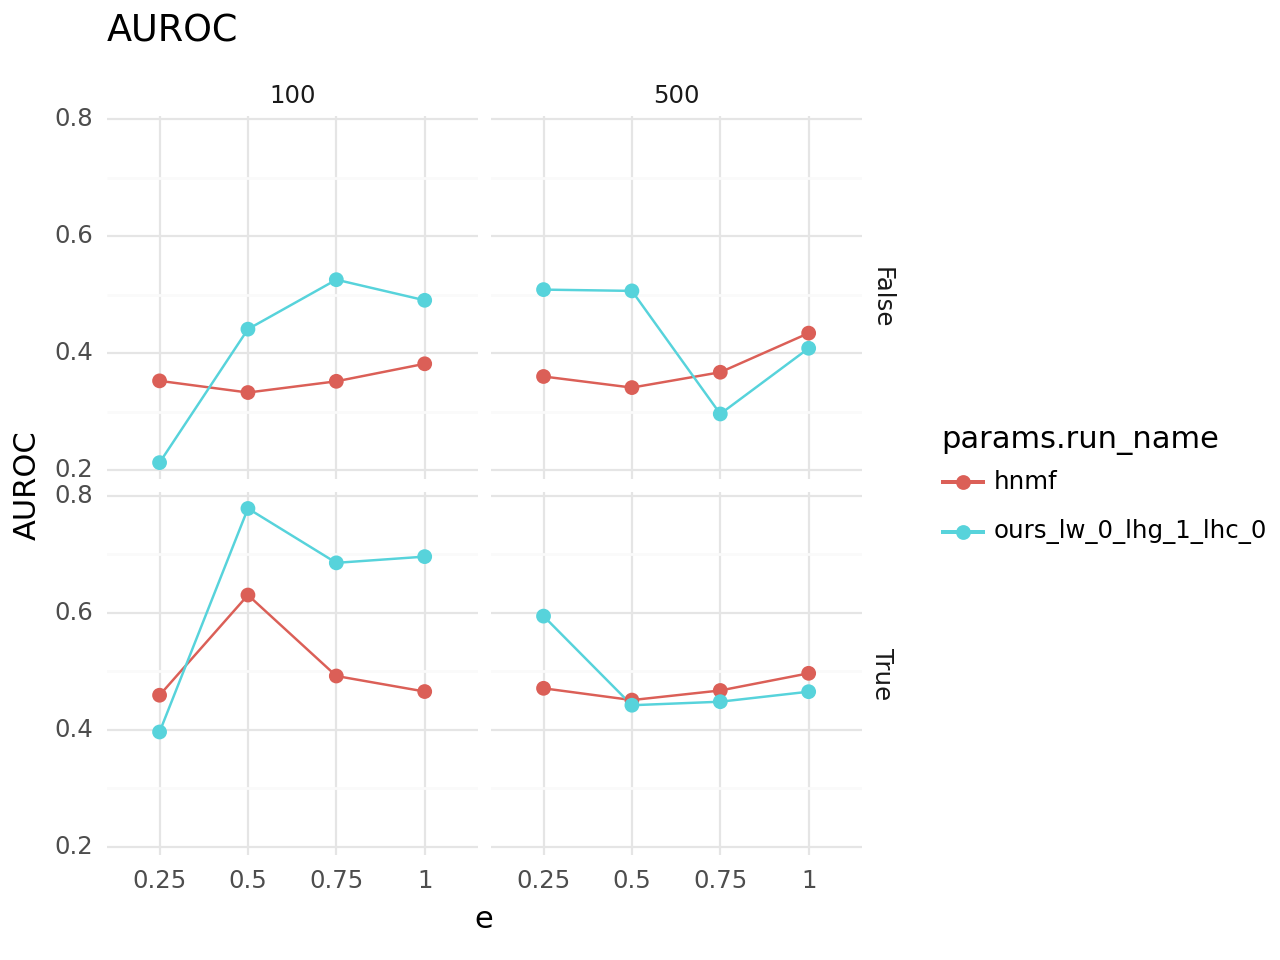

In [44]:
from plotnine import *
run_name = all_runs[all_runs['params.run_name'].str.startswith('ours')].sort_values('metrics.total_loss')[['params.run_name','metrics.total_loss']].head(1)['params.run_name'].values[0]
p = (
    ggplot(all_runs[all_runs['params.run_name'].isin(['hnmf',run_name])], aes(x="params.e", y="metrics.mean_cosine_sim", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_grid('params.ps ~ params.num_markers_assoc')
    + labs(x="e", y="AUROC", title="AUROC")
    + theme_minimal()
    + theme()
)
print(p)

In [61]:
all_runs.columns

Index(['run_id', 'experiment_id', 'status', 'artifact_uri', 'start_time',
       'end_time', 'metrics.mean_Brier', 'metrics.max mem', 'metrics.U_G_norm',
       'metrics.H_G_sparsity', 'metrics.Brier_0', 'metrics.Recall_1',
       'metrics.total_loss', 'metrics.AUPRC_1', 'metrics.NMI_1',
       'metrics.U_C_sparsity', 'metrics.W_sparsity', 'metrics.mean_AUROC',
       'metrics.H_G_norm', 'metrics.kl_div_loss', 'metrics.cosine_sim_0',
       'metrics.bce_loss', 'metrics.AUROC_0', 'metrics.F1_1',
       'metrics.H_C_norm', 'metrics.H_C_sparsity', 'metrics.mean_Precision',
       'metrics.user time', 'metrics.Brier_1', 'metrics.mean_AUPRC',
       'metrics.regularization', 'metrics.mean_Recall', 'metrics.Precision_0',
       'metrics.Precision_1', 'metrics.AUROC_1', 'metrics.Recall_0',
       'metrics.U_G_sparsity', 'metrics.W_norm', 'metrics.cosine_sim_1',
       'metrics.U_C_norm', 'metrics.cpu time', 'metrics.AUPRC_0',
       'metrics.mean_cosine_sim', 'metrics.mean_F1', 'metrics.NMI_0

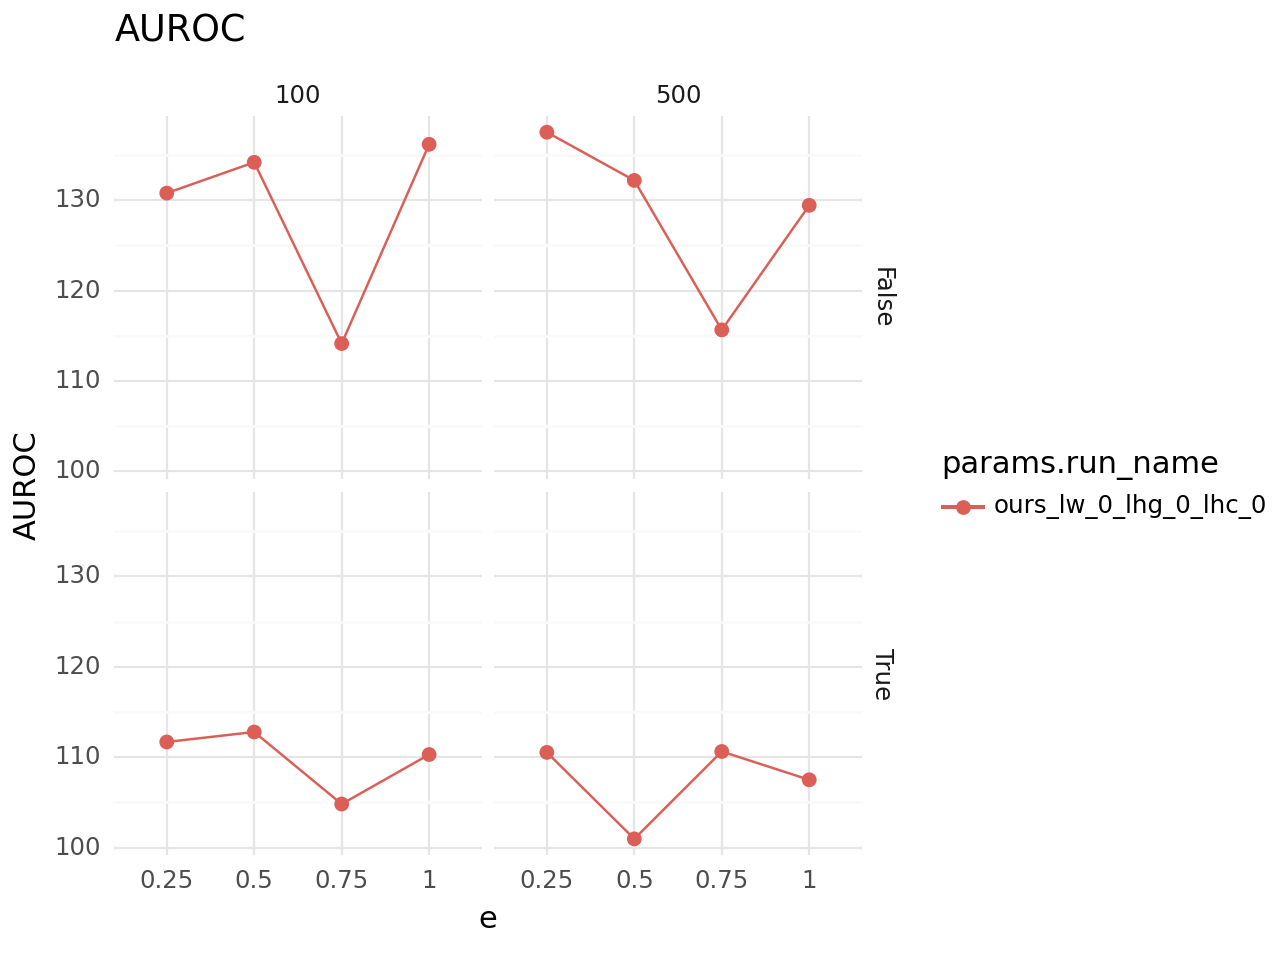

In [64]:
run_name = all_runs[all_runs['params.run_name'].str.startswith('ours')].sort_values('metrics.total_loss')[['params.run_name','metrics.total_loss']].head(1)['params.run_name'].values[0]
p = (
    ggplot(all_runs[all_runs['params.run_name'].isin(['ours_lw_0_lhg_0_lhc_0'])], aes(x="params.e", y="metrics.U_G_norm", color="params.run_name", group="params.run_name"))
    + geom_line()
    + geom_point(size=2)
    + facet_grid('params.ps ~ params.num_markers_assoc')
    + labs(x="e", y="AUROC", title="AUROC")
    + theme_minimal()
    + theme()
)
print(p)

In [66]:
import numpy as np
E_g = np.ones((2504,10000))
print(E_g.nbytes / 1e6, "MB")   # memory in MB

200.32 MB


U_G not any larger when pop. strat. is present

try without Z

In [ ]:
W = np.random.random((G.shape[0], rank))*1e-2+1e-6 
H_G = np.random.random((G.shape[1], rank))*1e-2+1e-6
H_C = np.random.random((C.shape[1], rank))*1e-2+1e-6
U_G = np.random.random((G.shape[1], Z.shape[1]))*1e-2+1e-6
U_C = np.random.random((C.shape[1], Z.shape[1]))*1e-2+1e-6
factor_matrices_noz, loss_function_noz = SCoNE.alternating_opt(G,C,np.zeros((Z.shape[0],Z.shape[1])),W, H_G, H_C, U_G, U_C,lambda_W, lambda_H_G, lambda_H_C, 
    method='L-BFGS-B',options={'maxcor':10, 'maxiter':10, 'gtol':1e-5, 'maxls':20, 'ftol':1e-6},tol=1e-4,nonneg=True)


In [160]:
compute_sim_metrics(W_true,factor_matrices_noz["W"])

0.8166904988299722
0.2510132066910599


/scratch/ipykernel_817605/1202321903.py:41: RuntimeWarning: invalid value encountered in divide


,true_subgroup_idx,pred_cluster_idx,similarity_AP,AUROC,AUPRC,Brier,F1,Precision,Recall,NMI
0,0,1,0.260744,0.398464,0.174417,0.50489,0.212698,0.165025,0.299107,0.000579
1,1,0,0.685812,0.841325,0.547307,0.12177,0.678694,0.594880,0.790000,0.297055


In [161]:
compute_sim_metrics(W_true,factor_matrices["W"])

0.34667023574975425
0.1263237732886745


,true_subgroup_idx,pred_cluster_idx,similarity_AP,AUROC,AUPRC,Brier,F1,Precision,Recall,NMI
0,0,1,0.434777,0.645817,0.289213,0.152692,0.362911,0.327928,0.40625,0.038680
1,1,0,0.680533,0.834608,0.560436,0.107429,0.678171,0.596358,0.78600,0.296035


In [165]:
simulation_metadata["clinical_assoc"]

,phenotypic_subgroup,strength,indices
0,0,0.6,"[35, 8, 62]"
1,0,0.5,"[78, 49, 92]"
2,0,0.4,"[83, 68, 27, 99]"
3,1,0.6,"[12, 53, 63]"
4,1,0.5,"[50, 99, 58]"
5,1,0.4,"[89, 29, 79, 3]"
6,2,0.6,"[13, 32, 60]"
7,2,0.5,"[66, 80, 89]"
8,2,0.4,"[85, 18, 69, 19]"
9,3,0.6,"[1, 51, 88]"


In [179]:
bfile_path = f'{output_dir}/G'
bim_df = pd.read_csv(f'{bfile_path}.bim',sep='\s+',header=None,names=['CHR','SNP','CM','POS','A1','A2']).reset_index(drop=True)
bim_df

,CHR,SNP,CM,POS,A1,A2
0,1,1:1151300,0,1151300,T,C
1,1,1:1371459,0,1371459,A,G
2,1,1:1510801,0,1510801,C,T
3,1,1:1648027,0,1648027,T,C
4,1,1:2914288,0,2914288,C,G
...,...,...,...,...,...,...
9995,22,22:50815104,0,50815104,T,C
9996,22,22:50937900,0,50937900,G,A
9997,22,22:51034177,0,51034177,G,A
9998,22,22:51156078,0,51156078,G,A


In [195]:
set(simulation_metadata["markers_assoc"][0]).intersection(set(simulation_metadata["markers_assoc"][1]))

{'2:110397539', '8:25777436'}

100
0


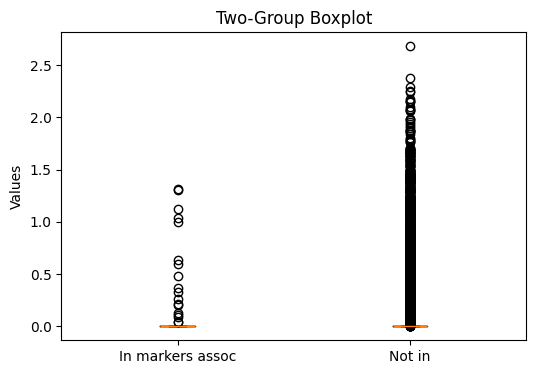

100
5


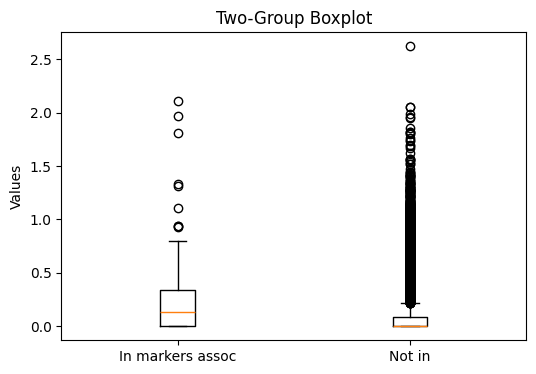

In [193]:
for i_true, j_pred in zip(row_ind, col_ind):
    top_idx = np.argsort(factor_matrices["H_G"][:,j_pred])[-num_markers_assoc:][::-1]
    top_markers = bim_df.loc[top_idx, "SNP"].values
    markers_assoc = simulation_metadata["markers_assoc"][i_true]
    print(len(markers_assoc))
    print(len(set(top_markers).intersection(set(markers_assoc))))

    idx_in = bim_df.index[bim_df["SNP"].isin(markers_assoc)].tolist()
    idx_not_in = bim_df.index[~bim_df["SNP"].isin(markers_assoc)].tolist()


    plt.figure(figsize=(6,4))
    plt.boxplot([factor_matrices["H_G"][:,j_pred][idx_in], factor_matrices["H_G"][:,j_pred][idx_not_in]], labels=["In markers assoc", "Not in"])

    plt.ylabel("Values")
    plt.title("Two-Group Boxplot")
    plt.show()


100
3


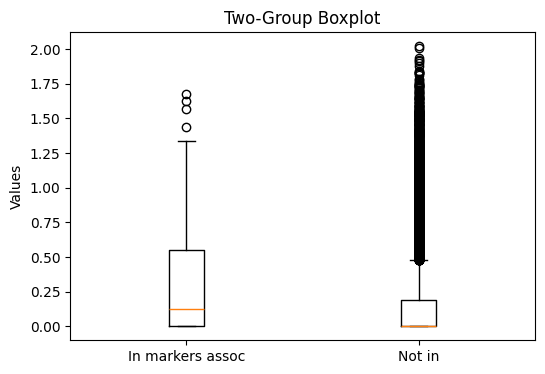

100
5


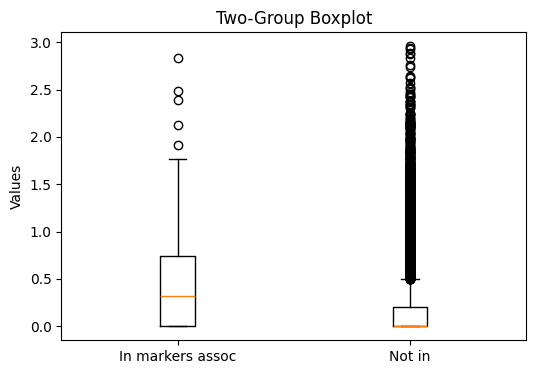

In [194]:
for i_true, j_pred in zip(row_ind, col_ind):
    top_idx = np.argsort(factor_matrices_noz["H_G"][:,j_pred])[-num_markers_assoc:][::-1]
    top_markers = bim_df.loc[top_idx, "SNP"].values
    markers_assoc = simulation_metadata["markers_assoc"][i_true]
    print(len(markers_assoc))
    print(len(set(top_markers).intersection(set(markers_assoc))))

    idx_in = bim_df.index[bim_df["SNP"].isin(markers_assoc)].tolist()
    idx_not_in = bim_df.index[~bim_df["SNP"].isin(markers_assoc)].tolist()


    plt.figure(figsize=(6,4))
    plt.boxplot([factor_matrices_noz["H_G"][:,j_pred][idx_in], factor_matrices_noz["H_G"][:,j_pred][idx_not_in]], labels=["In markers assoc", "Not in"])

    plt.ylabel("Values")
    plt.title("Two-Group Boxplot")
    plt.show()


In [28]:
import pandas as pd
from plotnine import *

df = pd.read_csv('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/data/simulations/output/eval_results.csv')
df.columns

Index(['Unnamed: 0', 'num_epochs', 'method', 'cosine_sim_0', 'AUROC_0',
       'AUPRC_0', 'Brier_0', 'F1_0', 'Precision_0', 'Recall_0', 'NMI_0',
       'cosine_sim_1', 'AUROC_1', 'AUPRC_1', 'Brier_1', 'F1_1', 'Precision_1',
       'Recall_1', 'NMI_1', 'mean_cosine_sim', 'mean_AUROC', 'mean_AUPRC',
       'mean_Brier', 'mean_F1', 'mean_Precision', 'mean_Recall', 'mean_NMI',
       'ps', 'e', 'init', 'num_markers_assoc', 'run_seed', 'tol', 'max_outer',
       'lambda_W', 'lambda_H_G', 'lambda_H_C', 'max mem', 'cpu time',
       'user time', 'W', 'H_G', 'H_C', 'U_G', 'U_C'],
      dtype='object')

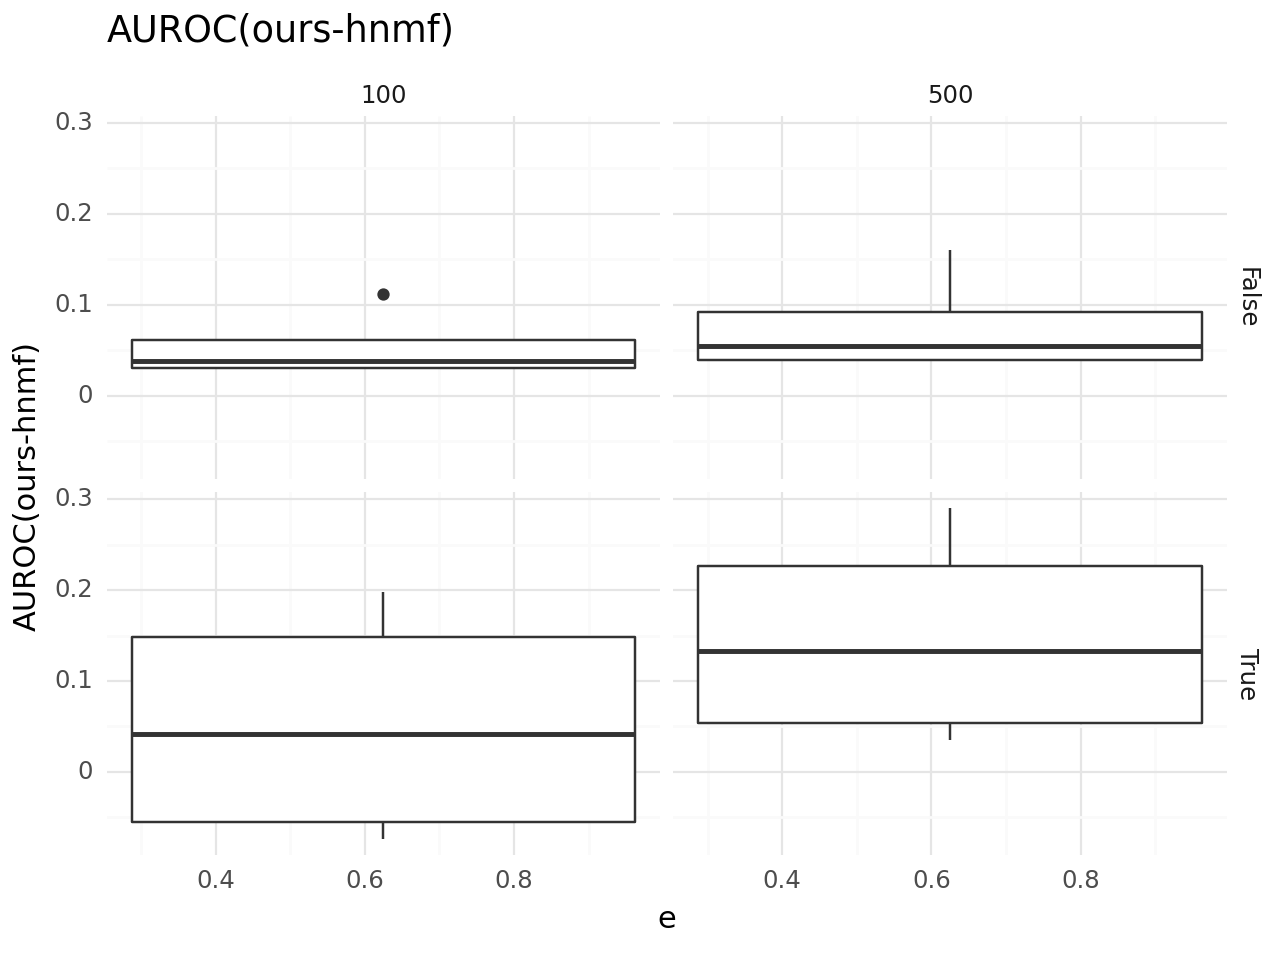

In [34]:
wide = (df.groupby(['ps','e','init','num_markers_assoc','method'])['mean_AUROC']
          .first()                         
          .unstack('method'))
wide = wide.reindex(columns=['ours','hnmf'])
out = (wide.iloc[:, 0] - wide.iloc[:, 1]).rename('AUROC(ours-hnmf)').reset_index()
p = (
    ggplot(out, aes(x="e", y="AUROC(ours-hnmf)"))
    + geom_boxplot()
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="AUROC(ours-hnmf)", title="AUROC(ours-hnmf)")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


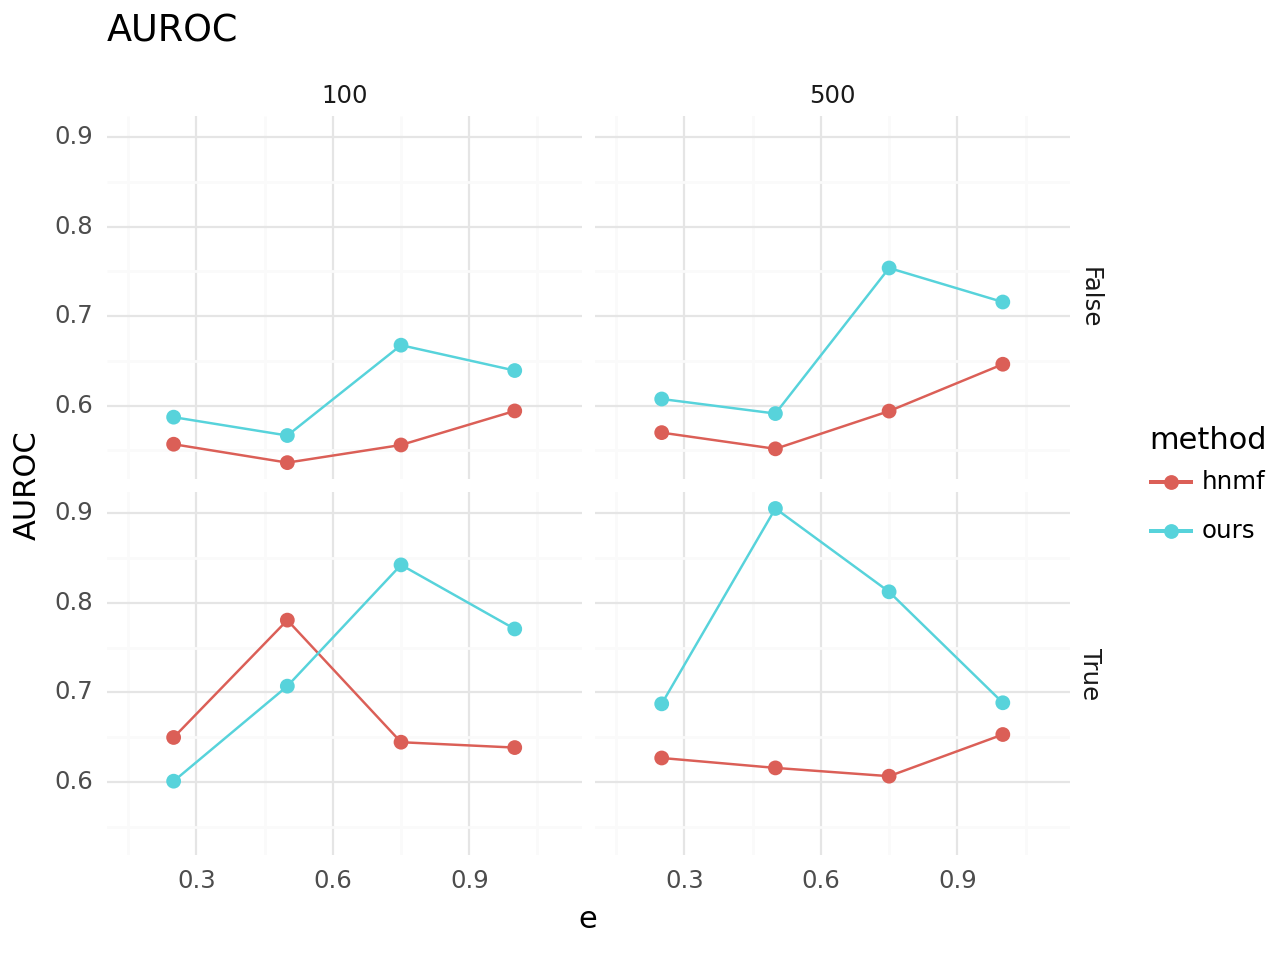

In [35]:
import scipy.stats as st
import numpy as np
def ci95(x):
    n = len(x)                     # number of runs
    mean = np.mean(x)              # average RMSE
    sd = np.std(x, ddof=1)         # sample standard deviation
    se = sd / np.sqrt(n)           # standard error of the mean
    margin = 1.96 * se          # margin of error
    return pd.Series({
        "mean": mean,
        "low": mean - margin,
        "high": mean + margin
    })
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_AUROC"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_AUROC').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="AUROC", title="AUROC")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


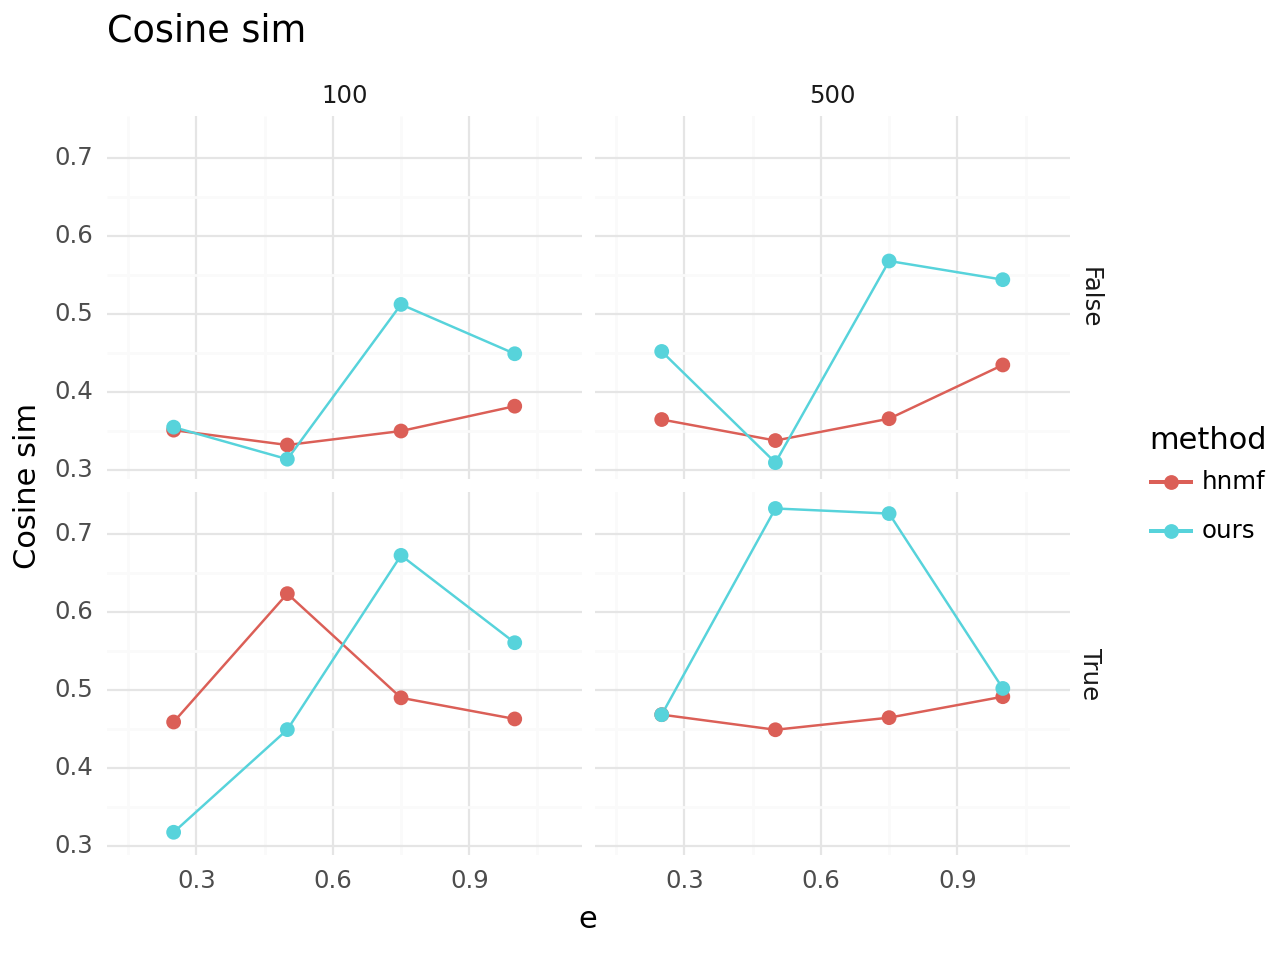

In [40]:
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_cosine_sim"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_cosine_sim').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="Cosine sim", title="Cosine sim")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


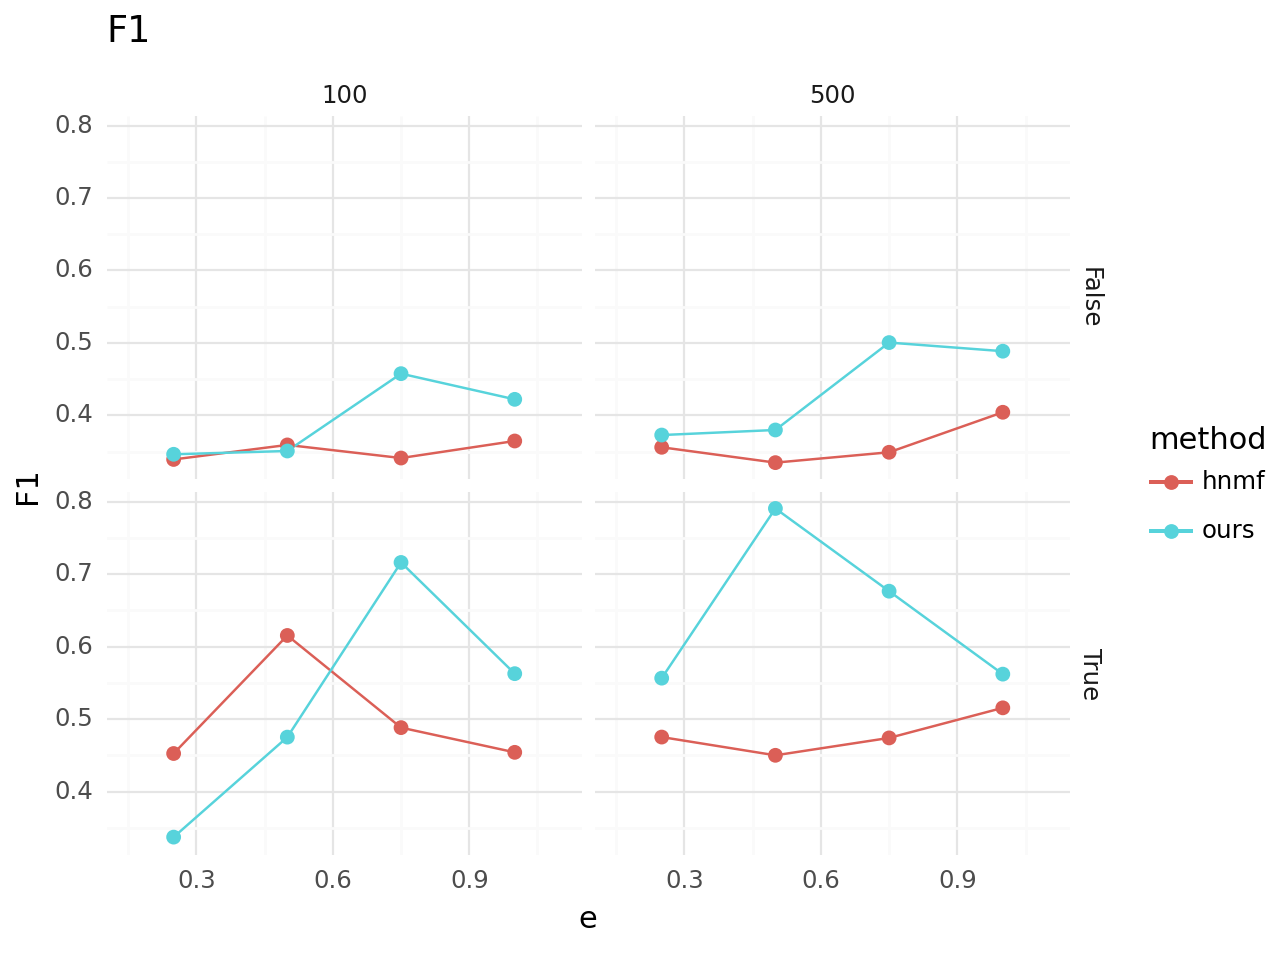

In [41]:
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_F1"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_F1').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="F1", title="F1")
    + theme_minimal()
)
print(p)

/gpfs/commons/home/anewbury/miniconda/envs/jupyter/lib/python3.9/site-packages/plotnine/layer.py:364: PlotnineWarning: geom_errorbar : Removed 32 rows containing missing values.


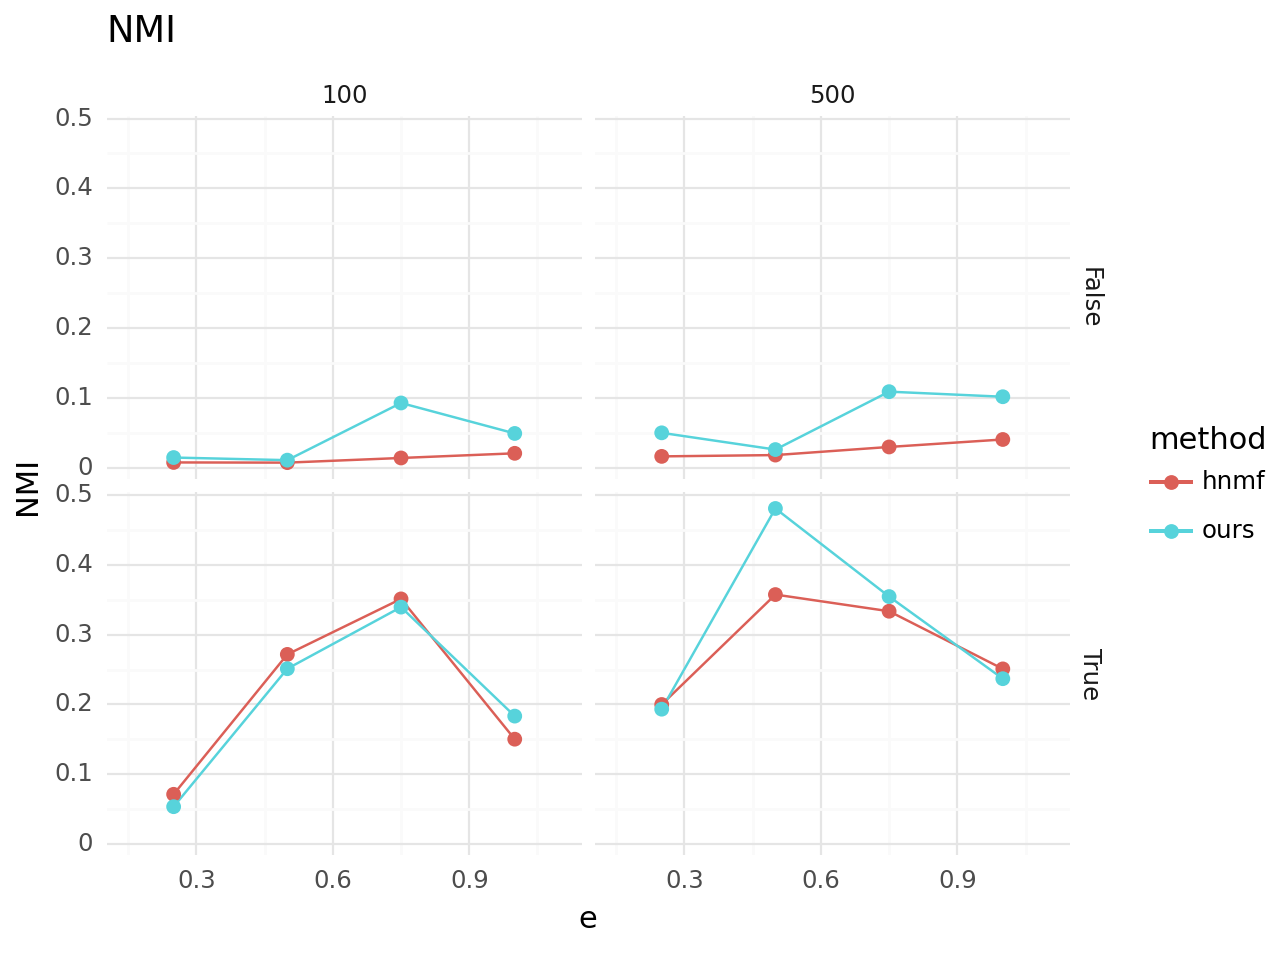

In [42]:
summary = df.groupby(["method","e","ps","num_markers_assoc"])["mean_NMI"].apply(ci95).reset_index()
summary = summary.pivot(index=["method","e","ps","num_markers_assoc"],columns='level_4',values='mean_NMI').reset_index().copy()
p = (
    ggplot(summary, aes(x="e", y="mean", color="method", group="method"))
    + geom_line()
    + geom_point(size=2)
    + geom_errorbar(aes(ymin="low", ymax="high"), width=0.2)
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="NMI", title="NMI")
    + theme_minimal()
)
print(p)

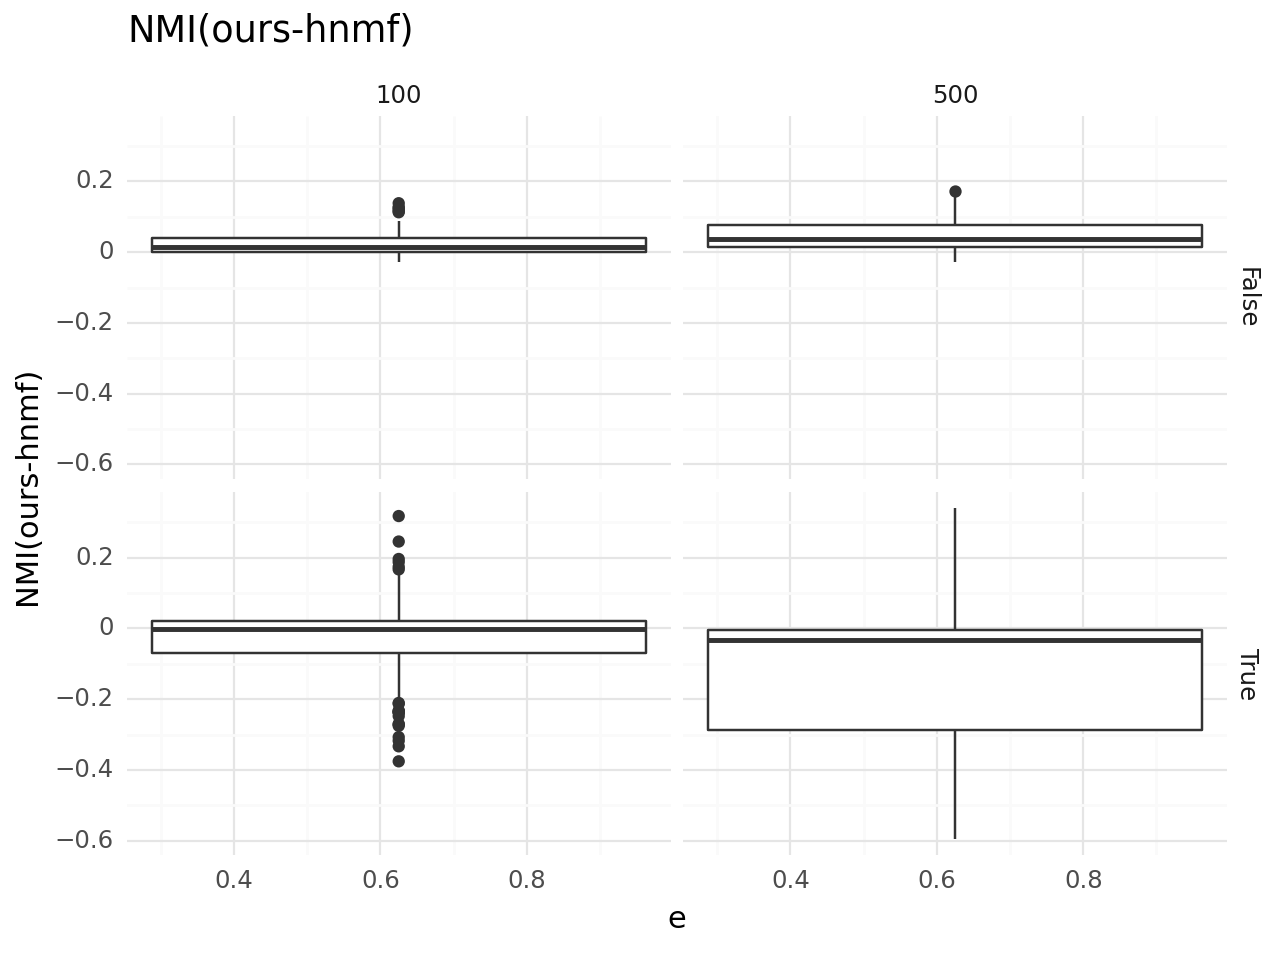

In [23]:
wide = (df.groupby(['true_subgroup_idx','ps','e','init','num_markers_assoc','algo_name'])['NMI']
          .first()                         
          .unstack('algo_name'))
wide = wide.reindex(columns=['ours','hnmf'])
out = (wide.iloc[:, 0] - wide.iloc[:, 1]).rename('NMI(ours-hnmf)').reset_index()
p = (
    ggplot(out, aes(x="e", y="NMI(ours-hnmf)"))
    + geom_boxplot()
    + facet_grid('ps ~ num_markers_assoc')
    + labs(x="e", y="NMI(ours-hnmf)", title="NMI(ours-hnmf)")
    + theme_minimal()
)
print(p)

In [13]:
import pickle
with open('/gpfs/commons/groups/gursoy_lab/anewbury/unsupervised_pheno/output/logs/743032177821795267/30eef9071bd6444ba28d7f683d067e25/artifacts/state_info/final_state.pkl', 'rb') as f:
    data = pickle.load(f)
data

{'W': array([[ 3.82980411,  0.32026128],
        [ 0.        ,  4.30205944],
        [ 4.53790586,  5.05810179],
        ...,
        [ 0.        ,  4.25512966],
        [13.37363813,  7.16925759],
        [ 0.        ,  0.        ]]),
 'H_G': array([[0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [0.        , 0.        ],
        [

In [2]:
import numpy as np
# Example W (3x2) and H (4x2)
W = np.array([[0.5, 1.0],
              [1.5, 2.0],
              [0.5, 3.0]])

H = np.array([[1, 2],
              [2, 1],
              [3, 1],
              [4, 2]])

norms = np.linalg.norm(W, axis=0)  # shape (k,)

# Avoid division by zero
norms[norms == 0] = 1.0

# Normalize columns of W
W = W / norms

# Scale rows of H
H = H * norms[np.newaxis, :] 


In [5]:
assert all(norms != 0)

In [12]:
H*norms

array([[ 2.75, 28.  ],
       [ 5.5 , 14.  ],
       [ 8.25, 14.  ],
       [11.  , 28.  ]])

In [11]:
norms

array([1.6583124 , 3.74165739])

In [10]:
H*norms[np.newaxis, :] 

array([[ 2.75, 28.  ],
       [ 5.5 , 14.  ],
       [ 8.25, 14.  ],
       [11.  , 28.  ]])

In [22]:
index_map

{(True, 0.25, 0, 100): 0,
 (True, 0.25, 0, 500): 1,
 (True, 0.75, 0, 100): 2,
 (True, 0.75, 0, 500): 3,
 (True, 0.5, 0, 100): 4,
 (True, 0.5, 0, 500): 5,
 (True, 1, 0, 100): 6,
 (True, 1, 0, 500): 7,
 (False, 0.25, 0, 100): 8,
 (False, 0.25, 0, 500): 9,
 (False, 0.75, 0, 100): 10,
 (False, 0.75, 0, 500): 11,
 (False, 0.5, 0, 100): 12,
 (False, 0.5, 0, 500): 13,
 (False, 1, 0, 100): 14,
 (False, 1, 0, 500): 15}

In [23]:
import numpy as np

def sparsity_percent(A):
    total = A.size
    zeros = np.count_nonzero(A == 0)
    return 100.0 * zeros / total

# Example
A = np.array([[1, 0, 3],
              [0, 0, 2],
              [4, 5, 0]])

print(f"Sparsity: {sparsity_percent(A):.2f}%")


Sparsity: 44.44%
